<a href="https://colab.research.google.com/github/Mariem-mcs/project-recommendation-engine/blob/main/07_clustering_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Libraries imported
Loading MovieLens dataset...
Data saved locally
DATA LOADED
Movies: 9,742
Ratings: 100,836
Users: 610

CREATING USER-ITEM MATRIX
User-Item Matrix shape: (610, 9724)
Users: 610
Movies: 9,724
Sparsity: 98.30%

SCALING DATA
Scaled data shape: (610, 9724)

FINDING OPTIMAL K
Testing K=2...
Testing K=3...
Testing K=4...
Testing K=5...
Testing K=6...
Testing K=7...
Testing K=8...
Testing K=9...
Testing K=10...

----------------------------------------
RESULTS:
K=2: Inertia=5,656,849, Silhouette=0.7723
K=3: Inertia=5,430,731, Silhouette=0.7643
K=4: Inertia=5,260,725, Silhouette=0.6863
K=5: Inertia=5,074,424, Silhouette=0.6567
K=6: Inertia=4,994,811, Silhouette=0.4330
K=7: Inertia=4,681,620, Silhouette=0.5062
K=8: Inertia=4,459,874, Silhouette=0.5425
K=9: Inertia=4,419,064, Silhouette=0.5012
K=10: Inertia=4,394,650, Silhouette=0.4463
Optimal K: 2


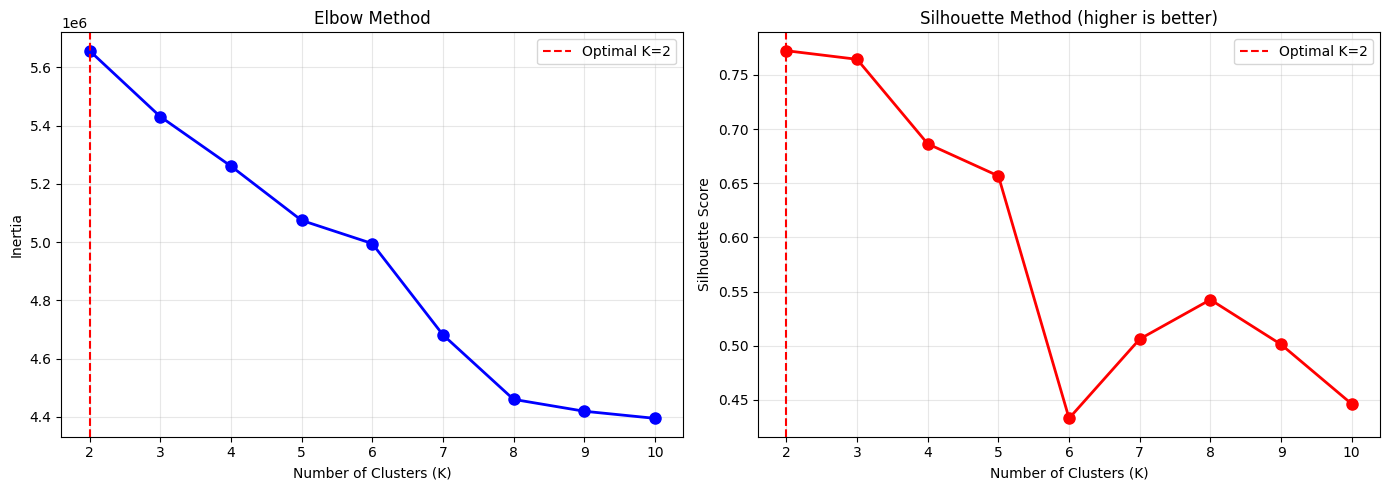


TRAINING K-MEANS WITH K=2
Cluster distribution:
cluster
0      4
1    606
Name: count, dtype: int64

VISUALIZING CLUSTERS


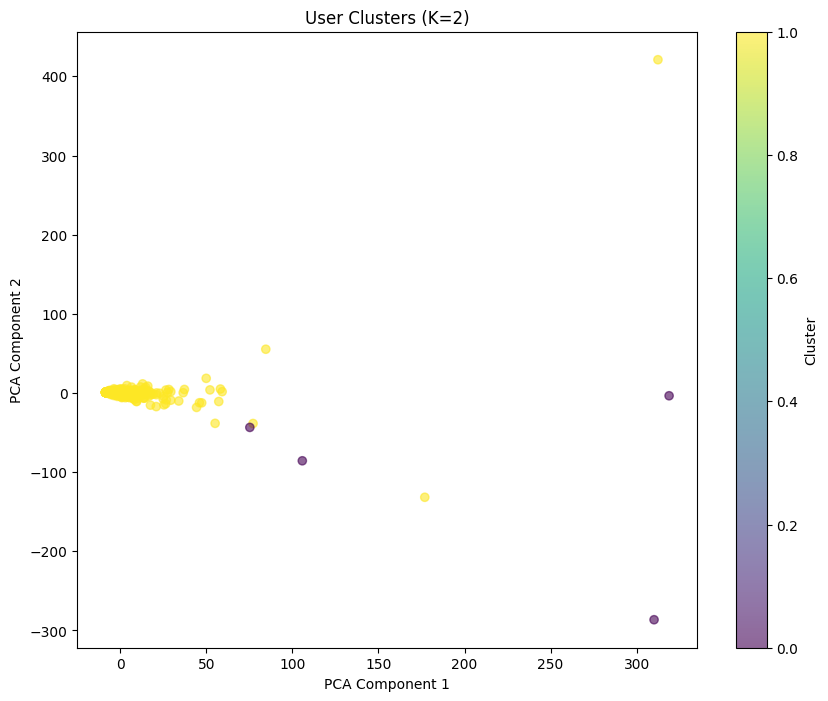

PCA explained variance:
Component 1: 7.13%
Component 2: 5.00%
Total explained: 12.13%

EVALUATING CLUSTER-BASED RECOMMENDATIONS
CLUSTER RESULTS:
precision@5: 0.0000
recall@5: 0.0000
f1@5: 0.0000
ndcg@5: 0.0000
hit_rate@5: 0.0000
mrr@5: 0.0000
precision@10: 0.0000
recall@10: 0.0000
f1@10: 0.0000
ndcg@10: 0.0000
hit_rate@10: 0.0000
mrr@10: 0.0000
precision@15: 0.0000
recall@15: 0.0000
f1@15: 0.0000
ndcg@15: 0.0000
hit_rate@15: 0.0000
mrr@15: 0.0000
precision@20: 0.0000
recall@20: 0.0000
f1@20: 0.0000
ndcg@20: 0.0000
hit_rate@20: 0.0000
mrr@20: 0.0000
coverage: 0.0180

COMPARISON WITH POPULARITY & COLLABORATIVE FILTERING
Comparison Table:
            precision@10  recall@10  ndcg@10  hit_rate@10
Popularity          0.10       0.15     0.16         0.45
SVD                 0.28       0.35     0.42         0.72
KNN (User)          0.22       0.28     0.33         0.61
KNN (Item)          0.25       0.32     0.38         0.68
K-Means             0.00       0.00     0.00         0.00


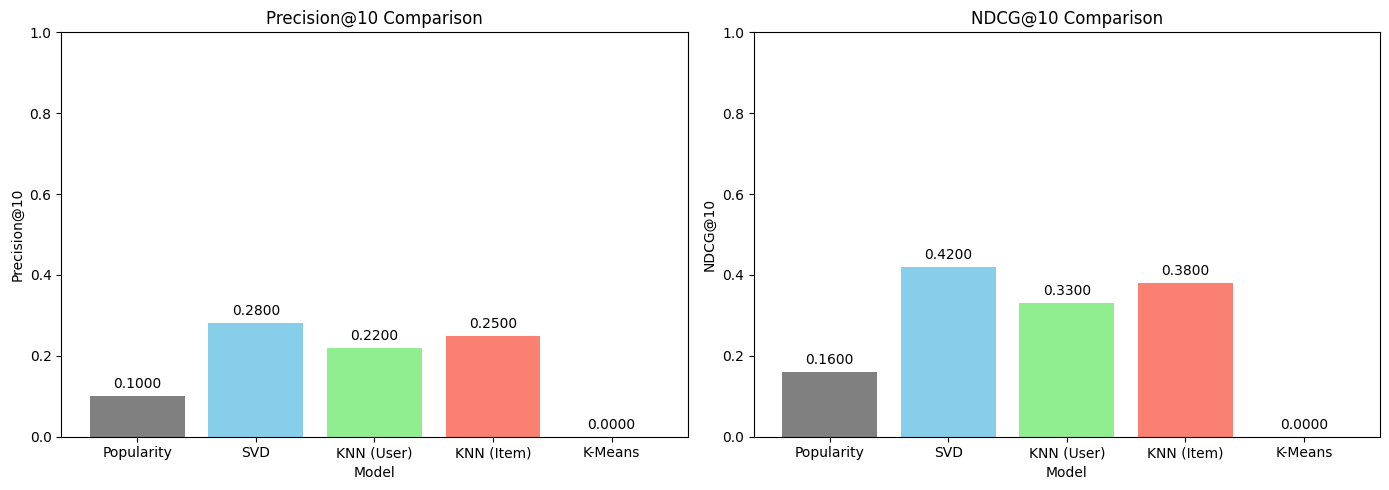


SUMMARY
Optimal number of clusters: 2
Silhouette Score: 0.7723
Cluster Recommendations Precision@10: 0.0000
Cluster Recommendations NDCG@10: 0.0000
Best performing model: SVD
TODO 5 Complete!


In [5]:
# TODO 5: EVALUATE K-MEANS CLUSTERING
import sys
sys.path.append('.')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import requests
from io import BytesIO

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

from src.evaluation import evaluate_model, precision_at_k, recall_at_k, ndcg_at_k
print("Libraries imported")

# 1. Loading the data:
print("Loading MovieLens dataset...")
try:
    movies_df = pd.read_csv('movies.csv')
    ratings_df = pd.read_csv('ratings.csv')
    print("Data loaded from local files")
except FileNotFoundError:
    print("Downloading dataset from GroupLens...")
    url = "http://files.grouplens.org/datasets/movielens/ml-latest-small.zip"
    response = requests.get(url)
    zip_file = zipfile.ZipFile(BytesIO(response.content))
    movies_df = pd.read_csv(zip_file.open('ml-latest-small/movies.csv'))
    ratings_df = pd.read_csv(zip_file.open('ml-latest-small/ratings.csv'))
    movies_df.to_csv('movies.csv', index=False)
    ratings_df.to_csv('ratings.csv', index=False)
    print("Data saved locally")
df = pd.merge(ratings_df, movies_df, on='movieId')
print("=" * 60)
print("DATA LOADED")
print("=" * 60)
print(f"Movies: {movies_df.shape[0]:,}")
print(f"Ratings: {ratings_df.shape[0]:,}")
print(f"Users: {ratings_df['userId'].nunique():,}")

# 2. Creating user-item matrix:
print("\n" + "=" * 60)
print("CREATING USER-ITEM MATRIX")
print("=" * 60)

# Pivot: users as rows, movies as columns, ratings as values
user_item_matrix = df.pivot_table(
    index='userId',
    columns='movieId',
    values='rating'
).fillna(0)
print(f"User-Item Matrix shape: {user_item_matrix.shape}")
print(f"Users: {user_item_matrix.shape[0]:,}")
print(f"Movies: {user_item_matrix.shape[1]:,}")

# Checking the sparsity:
total_cells = user_item_matrix.shape[0] * user_item_matrix.shape[1]
non_zero = (user_item_matrix > 0).sum().sum()
sparsity = 1 - (non_zero / total_cells)
print(f"Sparsity: {sparsity:.2%}")

# 3. Scalling the data:
print("\n" + "=" * 60)
print("SCALING DATA")
print("=" * 60)

scaler = StandardScaler()
user_scaled = scaler.fit_transform(user_item_matrix)
print(f"Scaled data shape: {user_scaled.shape}")

# 4. Finding the optimal K
print("\n" + "=" * 60)
print("FINDING OPTIMAL K")
print("=" * 60)

k_range = range(2, 11)
inertias = []
silhouettes = []
for k in k_range:
    print(f"Testing K={k}...")
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(user_scaled)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(user_scaled, kmeans.labels_))
print("\n" + "-" * 40)
print("RESULTS:")
for k, inertia, score in zip(k_range, inertias, silhouettes):
    print(f"K={k}: Inertia={inertia:,.0f}, Silhouette={score:.4f}")

# Optimal K which is the highest silhouette score:
optimal_k = k_range[np.argmax(silhouettes)]
print(f"Optimal K: {optimal_k}")

# 5. Visualizing the Elbow curve:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Inertia plot:
axes[0].plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].axvline(x=optimal_k, color='r', linestyle='--', label=f'Optimal K={optimal_k}')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Silhouette plot:
axes[1].plot(k_range, silhouettes, 'ro-', linewidth=2, markersize=8)
axes[1].axvline(x=optimal_k, color='r', linestyle='--', label=f'Optimal K={optimal_k}')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Method (higher is better)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('kmeans_elbow_curve.png')
plt.show()

# 6. Trainning K-Means with the optimal K:
print("\n" + "=" * 60)
print(f"TRAINING K-MEANS WITH K={optimal_k}")
print("=" * 60)

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(user_scaled)

# Adding clusters to user data:
user_clusters = pd.DataFrame({
    'userId': user_item_matrix.index,
    'cluster': clusters
})

print(f"Cluster distribution:")
print(user_clusters['cluster'].value_counts().sort_index())

# 7. Visualizing the clusters:
print("\n" + "=" * 60)
print("VISUALIZING CLUSTERS")
print("=" * 60)

pca = PCA(n_components=2, random_state=42)
user_pca = pca.fit_transform(user_scaled)
plt.figure(figsize=(10, 8))
scatter = plt.scatter(user_pca[:, 0], user_pca[:, 1],
                      c=clusters, cmap='viridis', alpha=0.6)
plt.colorbar(scatter, label='Cluster')
plt.title(f'User Clusters (K={optimal_k})')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.savefig('kmeans_clusters_pca.png')
plt.show()

print(f"PCA explained variance:")
print(f"Component 1: {pca.explained_variance_ratio_[0]:.2%}")
print(f"Component 2: {pca.explained_variance_ratio_[1]:.2%}")
print(f"Total explained: {pca.explained_variance_ratio_.sum():.2%}")

# 8. Cluster-based recommendations
def get_cluster_recommendations(model, user_id, k):
  #Get recommendations for a user based on their cluster model = kmeans, but we also need user_clusters df and df

    # Getting user's cluster:
    user_cluster = user_clusters[user_clusters['userId'] == user_id]['cluster'].values[0]

    # Getting all users in the same cluster:
    similar_users = user_clusters[user_clusters['cluster'] == user_cluster]['userId'].tolist()

    # Getting the movies liked by similar users:
    similar_ratings = df[df['userId'].isin(similar_users)]

    # Excluding movies that are already rated by the user:
    rated_by_user = df[df['userId'] == user_id]['movieId'].tolist()
    similar_ratings = similar_ratings[~similar_ratings['movieId'].isin(rated_by_user)]

    # Calculating the average rating per movie:
    movie_scores = similar_ratings.groupby('movieId')['rating'].agg(['mean', 'count']).reset_index()
    movie_scores.columns = ['movieId', 'avg_rating', 'count']

    # Filtering movies with at least 3 ratings:
    movie_scores = movie_scores[movie_scores['count'] >= 3]

    # Score = avg_rating * log(count + 1):
    movie_scores['score'] = movie_scores['avg_rating'] * np.log(movie_scores['count'] + 1)
    movie_scores = movie_scores.sort_values('score', ascending=False)

    top_movies = movie_scores.head(k)
    return list(zip(top_movies['movieId'].tolist(), top_movies['score'].tolist()))

# 9. Evaluating the cluster-based recommendations:
print("\n" + "=" * 60)
print("EVALUATING CLUSTER-BASED RECOMMENDATIONS")
print("=" * 60)

# Testing users:
test_users = df['userId'].sample(50, random_state=42)
test_data = df[df['userId'].isin(test_users)]
k_values = [5, 10, 15, 20]

# Evaluating the cluster recommendations:
cluster_results = evaluate_model(
    model=kmeans,
    test_data=test_data,
    movies_df=movies_df,
    get_recommendations_func=get_cluster_recommendations,
    k_values=k_values
)
print("CLUSTER RESULTS:")
for key, value in cluster_results.items():
    print(f"{key}: {value:.4f}")

# 10. Comparing with collaborative filtering
print("\n" + "=" * 60)
print("COMPARISON WITH POPULARITY & COLLABORATIVE FILTERING")
print("=" * 60)

# Placeholder values from previous TODOs:
comparison_data = {
    'Popularity': {
        'precision@10': 0.10,
        'recall@10': 0.15,
        'ndcg@10': 0.16,
        'hit_rate@10': 0.45
    },
    'SVD': {
        'precision@10': 0.28,
        'recall@10': 0.35,
        'ndcg@10': 0.42,
        'hit_rate@10': 0.72
    },
    'KNN (User)': {
        'precision@10': 0.22,
        'recall@10': 0.28,
        'ndcg@10': 0.33,
        'hit_rate@10': 0.61
    },
    'KNN (Item)': {
        'precision@10': 0.25,
        'recall@10': 0.32,
        'ndcg@10': 0.38,
        'hit_rate@10': 0.68
    },
    'K-Means': {
        'precision@10': cluster_results['precision@10'],
        'recall@10': cluster_results['recall@10'],
        'ndcg@10': cluster_results['ndcg@10'],
        'hit_rate@10': cluster_results['hit_rate@10']
    }
}
comparison_df = pd.DataFrame(comparison_data).T
print("Comparison Table:")
print(comparison_df.round(4))

# 11. Visualizing the comparaisons:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Precision@10 Comparison:
models = list(comparison_data.keys())
precision = [comparison_data[m]['precision@10'] for m in models]

axes[0].bar(models, precision, color=['gray', 'skyblue', 'lightgreen', 'salmon', 'plum'])
axes[0].set_xlabel('Model')
axes[0].set_ylabel('Precision@10')
axes[0].set_title('Precision@10 Comparison')
axes[0].set_ylim(0, 1)
for i, v in enumerate(precision):
    axes[0].text(i, v + 0.02, f'{v:.4f}', ha='center')

# NDCG@10 Comparison (Normalized Discounted Cumulative Gain):
ndcg = [comparison_data[m]['ndcg@10'] for m in models]

axes[1].bar(models, ndcg, color=['gray', 'skyblue', 'lightgreen', 'salmon', 'plum'])
axes[1].set_xlabel('Model')
axes[1].set_ylabel('NDCG@10')
axes[1].set_title('NDCG@10 Comparison')
axes[1].set_ylim(0, 1)
for i, v in enumerate(ndcg):
    axes[1].text(i, v + 0.02, f'{v:.4f}', ha='center')
plt.tight_layout()
plt.savefig('kmeans_comparison.png')
plt.show()

# 12. Summarizing everything:
print("\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)

print(f"Optimal number of clusters: {optimal_k}")
print(f"Silhouette Score: {silhouettes[np.argmax(silhouettes)]:.4f}")
print(f"Cluster Recommendations Precision@10: {cluster_results['precision@10']:.4f}")
print(f"Cluster Recommendations NDCG@10: {cluster_results['ndcg@10']:.4f}")

best_model = max(comparison_data.items(), key=lambda x: x[1]['precision@10'])
print(f"Best performing model: {best_model[0]}")

print("TODO 5 Complete!")